Module 8 Case study 1

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_digits
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [4]:
#1 Scikit learn comes with the pre-loaded dataset, load the digits dataset from that collection 
# and write a helper function to plot the image using matplotlib.
# [Hint:Explore datasets module from scikit learn]

digits = load_digits()

In [5]:
print(digits.data.shape)
print(digits.images.shape)

(1797, 64)
(1797, 8, 8)


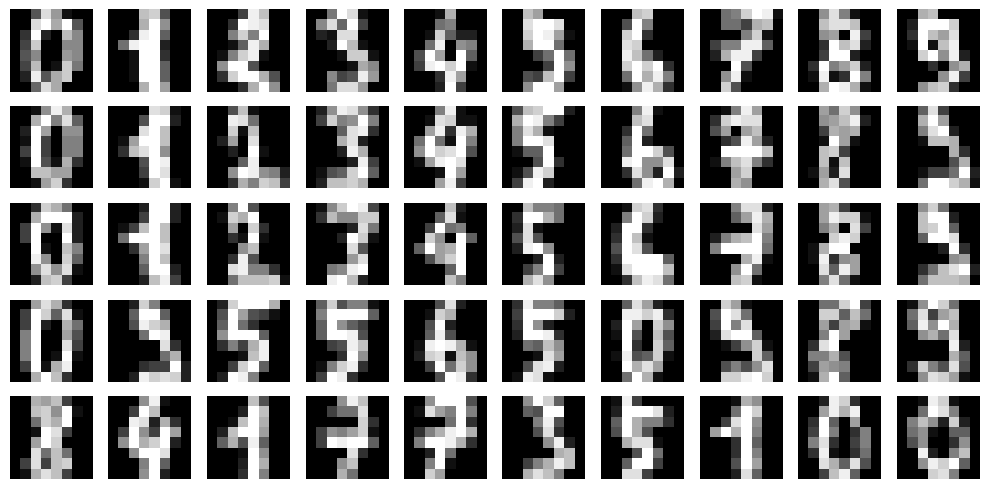

In [ ]:
# helper function to display dataset images

def plot_image(row, col, w, h):
    fig, axes = plt.subplots(row, col, figsize=(w,h))
    axes = axes.flatten()
    for i in range(len(axes)):      
        axes[i].imshow(digits.images[i], cmap='gray')
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

# call the function
plot_image(5,10,10,5)

# alternatively start end can also be explored to traverse through the image set

In [70]:
print(digits.keys())
print(digits.data)
digits.target

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])
[[ 0.  0.  5. ...  0.  0.  0.]
 [ 0.  0.  0. ... 10.  0.  0.]
 [ 0.  0.  0. ... 16.  9.  0.]
 ...
 [ 0.  0.  1. ...  6.  0.  0.]
 [ 0.  0.  2. ... 12.  0.  0.]
 [ 0.  0. 10. ... 12.  1.  0.]]


array([0, 1, 2, ..., 8, 9, 8], shape=(1797,))

In [118]:
df = pd.DataFrame(digits.data, columns=digits.feature_names)
df.head()

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_6,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0


In [119]:
#2 Make a train-testsplit with 20% of the data set aside for testing.
# Fit a logistic regression model and observe the accuracy.

X = df
y = digits.target

# scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2)

# fit the model
model = LogisticRegression(max_iter=165)
model.fit(X_train,y_train)

# predict the results
ypred = model.predict(X_test)

# Accuracy score
score1 = accuracy_score(y_test,ypred)
print(score1)

# Cross validation score
cv1 = cross_val_score(model, X, y, cv=5, scoring='accuracy').mean()
print(cv1)

0.9611111111111111
0.914322191272052


In [90]:
X.shape

(1797, 64)

In [120]:
#3 Using scikit learn perform a PCA transformation such that the transformed dataset can explain 
# 95% of the variance in the original dataset. 
# Find out the number of components in the projected subspace.
# [Hint:Refer to decomposition module of scikit learn]

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)
print(X_pca.shape)
print('No. of components in the projected subspace:', pca.n_components_)

(1797, 40)
No. of components in the projected subspace: 40


In [124]:
#4 Transform the dataset and fit a logistic regression and observe the accuracy. 
# Compare it with the previous model and comment on the accuracy.
# [Hint: Project both the train and test samples to the new subspace]

X_train2, X_test2, y_train2, y_test2 = train_test_split(X_pca, y, test_size=0.2)

# fit the model
model2 = LogisticRegression(max_iter=165)
model2.fit(X_train2,y_train2)

# predict the results
ypred2 = model2.predict(X_test2)

# Accuracy score
score2 = accuracy_score(y_test2,ypred2)
print(score2)

# Cross validation score
cv2 = cross_val_score(model2, X_pca, y, cv=5, scoring='accuracy').mean()
print(cv2)

0.9777777777777777
0.9137666357164964


[[28  0  0  0  0  0  0  1  0  0]
 [ 0 28  0  0  0  0  0  0  0  0]
 [ 0  0 37  0  0  0  0  0  0  0]
 [ 0  0  1 35  0  1  0  0  0  0]
 [ 0  0  0  0 40  0  0  0  0  0]
 [ 0  0  0  0  1 39  0  0  0  0]
 [ 0  0  0  0  0  0 36  0  0  0]
 [ 0  0  0  0  0  0  0 43  0  0]
 [ 0  1  0  0  0  1  1  0 35  0]
 [ 0  0  0  0  0  0  0  0  1 31]]
8


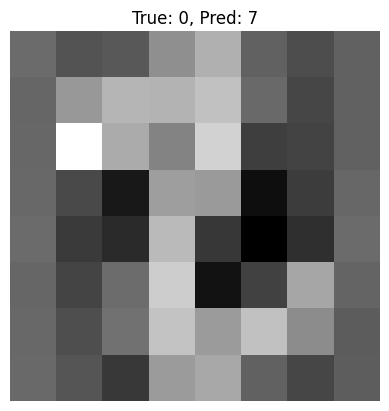

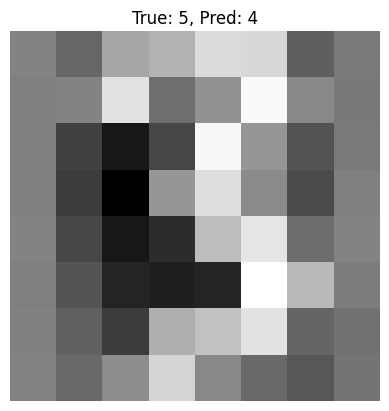

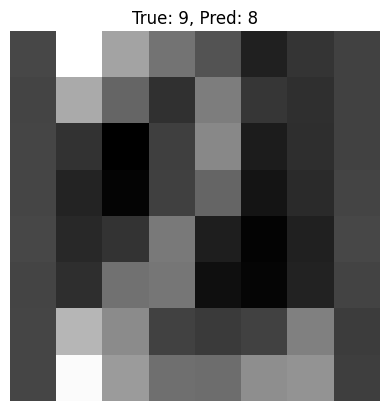

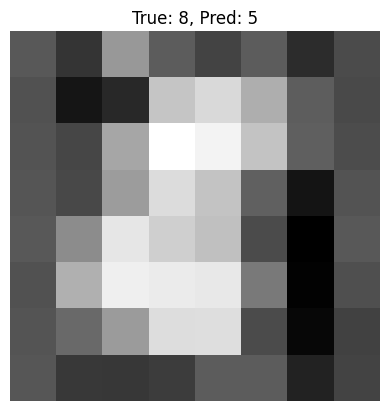

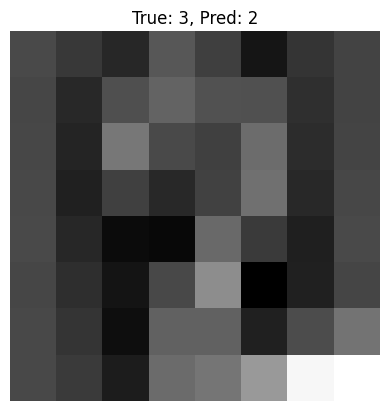

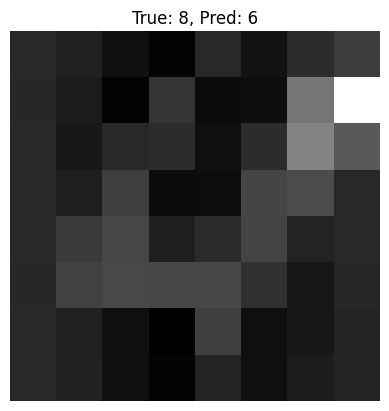

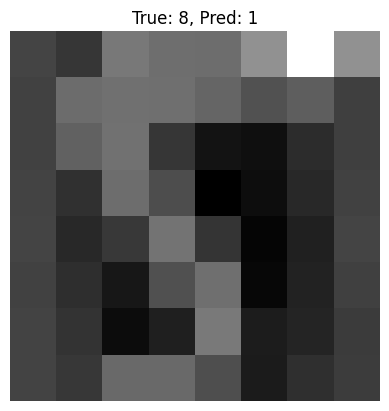

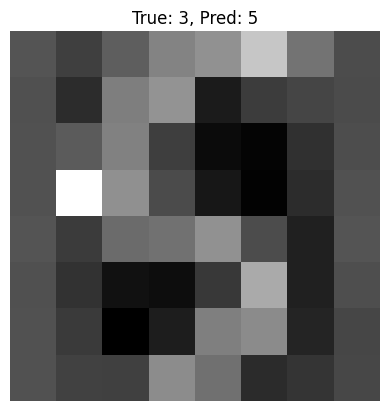

In [132]:
#5 Compute the confusion matrix and count the number of instances that have gone wrong. 
# For each wrong sample, plot the digit along with the predicted and original label.

cm = confusion_matrix(y_test2,ypred2)
print(cm)

# no.of instances misclassified
errors = (y_test2 != ypred2)
print(errors.sum())

for i in range(len(y_test2)):
    if errors[i]:  # Check if misclassified
        plt.imshow(X_test[i].reshape(8, 8), cmap='gray')
        plt.title(f"True: {y_test2[i]}, Pred: {ypred2[i]}")
        plt.axis('off')
        plt.show()